# **CAR PRICE PREDICTION**

### Adarsh Patidar

In [1]:
import pandas as pd 
import numpy as np

In [2]:
df=pd.read_csv("cardekho_dataset.csv")

In [3]:
df.head()

,Unnamed: 0,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,0,Maruti Alto,Maruti,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000
1,1,Hyundai Grand,Hyundai,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000
2,2,Hyundai i20,Hyundai,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000
3,3,Maruti Alto,Maruti,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000
4,4,Ford Ecosport,Ford,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000


In [4]:
df.tail()

,Unnamed: 0,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
15406,19537,Hyundai i10,Hyundai,i10,9,10723,Dealer,Petrol,Manual,19.81,1086,68.05,5,250000
15407,19540,Maruti Ertiga,Maruti,Ertiga,2,18000,Dealer,Petrol,Manual,17.50,1373,91.10,7,925000
15408,19541,Skoda Rapid,Skoda,Rapid,6,67000,Dealer,Diesel,Manual,21.14,1498,103.52,5,425000
15409,19542,Mahindra XUV500,Mahindra,XUV500,5,3800000,Dealer,Diesel,Manual,16.00,2179,140.00,7,1225000
15410,19543,Honda City,Honda,City,2,13000,Dealer,Petrol,Automatic,18.00,1497,117.60,5,1200000


In [5]:
df.isnull().sum()

Unnamed: 0           0
car_name             0
brand                0
model                0
vehicle_age          0
km_driven            0
seller_type          0
fuel_type            0
transmission_type    0
mileage              0
engine               0
max_power            0
seats                0
selling_price        0
dtype: int64

In [6]:
df.columns

Index(['Unnamed: 0', 'car_name', 'brand', 'model', 'vehicle_age', 'km_driven',
       'seller_type', 'fuel_type', 'transmission_type', 'mileage', 'engine',
       'max_power', 'seats', 'selling_price'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15411 entries, 0 to 15410
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         15411 non-null  int64  
 1   car_name           15411 non-null  object 
 2   brand              15411 non-null  object 
 3   model              15411 non-null  object 
 4   vehicle_age        15411 non-null  int64  
 5   km_driven          15411 non-null  int64  
 6   seller_type        15411 non-null  object 
 7   fuel_type          15411 non-null  object 
 8   transmission_type  15411 non-null  object 
 9   mileage            15411 non-null  float64
 10  engine             15411 non-null  int64  
 11  max_power          15411 non-null  float64
 12  seats              15411 non-null  int64  
 13  selling_price      15411 non-null  int64  
dtypes: float64(2), int64(6), object(6)
memory usage: 1.6+ MB


In [8]:
df.describe()

,Unnamed: 0,vehicle_age,km_driven,mileage,engine,max_power,seats,selling_price
count,15411.000000,15411.000000,1.541100e+04,15411.000000,15411.000000,15411.000000,15411.000000,1.541100e+04
mean,9811.857699,6.036338,5.561648e+04,19.701151,1486.057751,100.588254,5.325482,7.749711e+05
std,5643.418542,3.013291,5.161855e+04,4.171265,521.106696,42.972979,0.807628,8.941284e+05
min,0.000000,0.000000,1.000000e+02,4.000000,793.000000,38.400000,0.000000,4.000000e+04
25%,4906.500000,4.000000,3.000000e+04,17.000000,1197.000000,74.000000,5.000000,3.850000e+05
50%,9872.000000,6.000000,5.000000e+04,19.670000,1248.000000,88.500000,5.000000,5.560000e+05
75%,14668.500000,8.000000,7.000000e+04,22.700000,1582.000000,117.300000,5.000000,8.250000e+05
max,19543.000000,29.000000,3.800000e+06,33.540000,6592.000000,626.000000,9.000000,3.950000e+07


In [9]:
transmission_type_count=df["transmission_type"].value_counts()

In [10]:
fuel_count=df["fuel_type"].value_counts() 

In [11]:
seller_count=df["seller_type"].value_counts()

In [12]:
seats_count=df["seats"].value_counts()

In [13]:
df.rename(columns={
    "Unnamed: 0": "car_id"
}, inplace=True)

In [14]:
df.columns.tolist()

['car_id',
 'car_name',
 'brand',
 'model',
 'vehicle_age',
 'km_driven',
 'seller_type',
 'fuel_type',
 'transmission_type',
 'mileage',
 'engine',
 'max_power',
 'seats',
 'selling_price']

In [15]:
df.shape

(15411, 14)

## Phase 2 ( Visualizetion )

In [16]:
import matplotlib.pyplot as plt

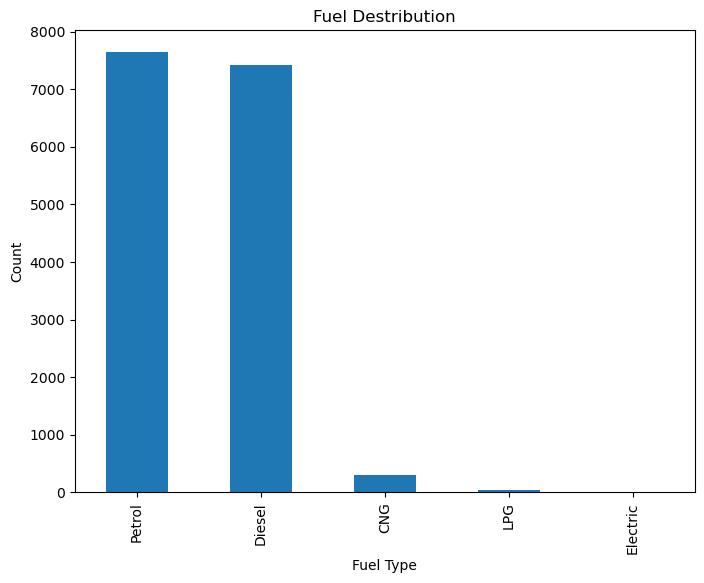

In [92]:
plt.figure(figsize=(8,6))
fuel_count.plot( kind="bar")
plt.xlabel("Fuel Type")
plt.ylabel("Count")
plt.title("Fuel Destribution")
plt.show()

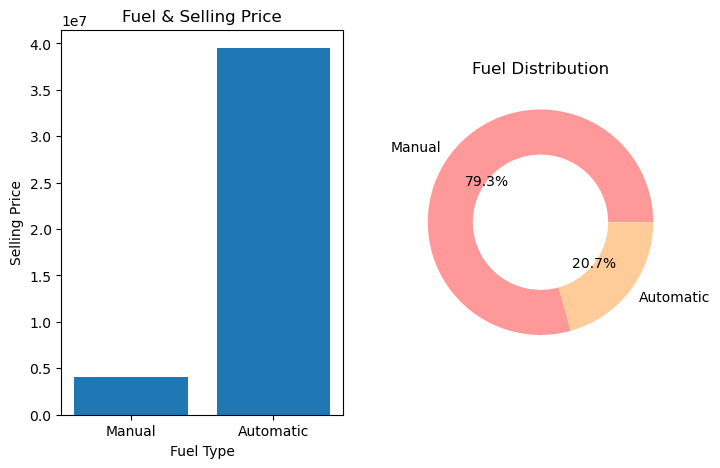

In [18]:
plt.figure(figsize=(8,5))
plt.subplot(1,2,1)
plt.bar(df["transmission_type"],df["selling_price"])

plt.title("Fuel & Selling Price")
plt.xlabel("Fuel Type")
plt.ylabel("Selling Price")

plt.subplot(1,2,2)
colors=['#FF9999','#FFCC99']
plt.pie(transmission_type_count,labels=transmission_type_count.index,wedgeprops=dict(width=0.4),autopct="%1.1f%%",colors=colors)
plt.title("Fuel Distribution")

plt.show()

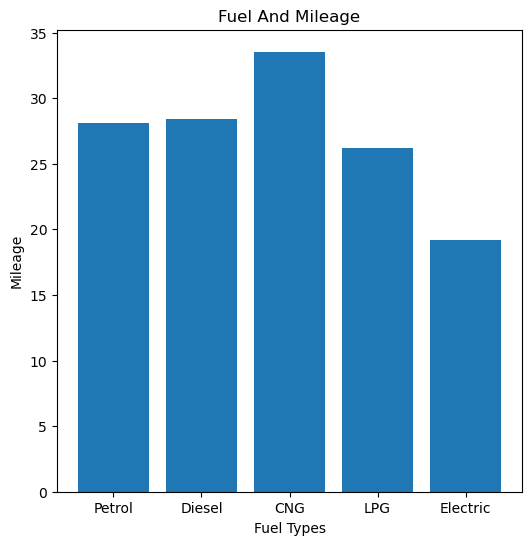

In [82]:
plt.figure(figsize=(6,6))
plt.bar(df["fuel_type"],df["mileage"])
plt.title("Fuel And Mileage")
plt.xlabel("Fuel Types")
plt.ylabel("Mileage")
plt.show()

### Create Price Catagory Columns 

In [23]:
df["price_cat"] = pd.qcut(
    df["selling_price"],
    q=5,
    labels=[1,2,3,4,5]
)

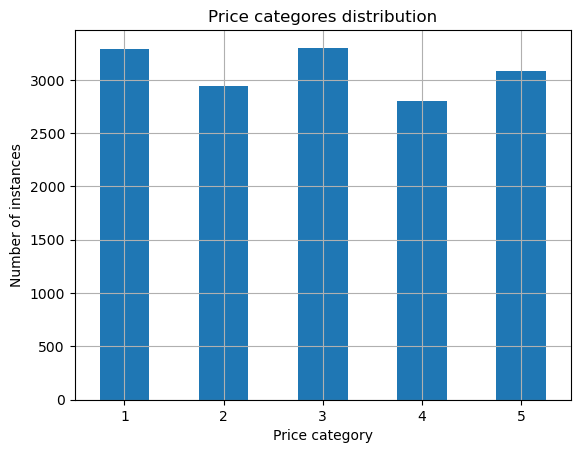

In [24]:
df["price_cat"].value_counts().sort_index().plot.bar(rot=0,grid=True)
plt.title("Price categores distribution")
plt.xlabel("Price category")
plt.ylabel("Number of instances")
plt.show()


### shuffle the data by the halpe of price_cat and remove the column

In [26]:
df.head(1)

,car_id,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price,price_cat
0,0,Maruti Alto,Maruti,Alto,9,120000,Individual,Petrol,Manual,19.7,796,46.3,5,120000,1


In [27]:
from sklearn.model_selection import StratifiedShuffleSplit
split=StratifiedShuffleSplit(n_splits=1,test_size=0.2,random_state=42)

for train_index,test_index in split.split(df,df["price_cat"]):
    strat_train_set=df.loc[train_index].drop("price_cat",axis=1)
    strat_test_set=df.loc[test_index].drop("price_cat",axis=1)


In [28]:
strat_train_set.shape

(12328, 14)

In [29]:
strat_test_set.shape

(3083, 14)

In [30]:
car=strat_train_set.copy()

In [31]:
car.head(2)

,car_id,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
11534,14638,Maruti Swift Dzire,Maruti,Swift Dzire,10,83000,Individual,Petrol,Manual,17.50,1298,85.8,5,220000
5771,7356,Maruti Alto,Maruti,Alto,6,50000,Individual,Petrol,Manual,22.74,796,47.3,5,220000


In [32]:
car.shape

(12328, 14)

In [33]:
car_labels=car["selling_price"].copy()  # y(output)
car=car.drop("selling_price",axis=1)   #X (input)


In [34]:
num_attribs=car.drop(columns=[ "car_id","car_name","brand","model","seller_type","fuel_type","transmission_type"]).columns.tolist()
cat_attribs=car.drop(columns=[ "car_id","vehicle_age","km_driven","mileage","engine","max_power","seats"]).columns.tolist()

In [35]:
num_attribs

['vehicle_age', 'km_driven', 'mileage', 'engine', 'max_power', 'seats']

In [36]:
cat_attribs

['car_name', 'brand', 'model', 'seller_type', 'fuel_type', 'transmission_type']

In [38]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler,OneHotEncoder


### Num Pipeline

In [40]:
num_pipeline=Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",StandardScaler())
])

### Cat Pipeline 

In [42]:
cat_pipeline=Pipeline([
    ("onehot",OneHotEncoder(handle_unknown="ignore")),
    
])

### Full Pipeline

In [43]:
full_pipeline=ColumnTransformer([
    ("num",num_pipeline,num_attribs),
    ("cat",cat_pipeline,cat_attribs)
])

In [44]:
car_features=full_pipeline.fit_transform(car)

In [45]:
car_features.shape

(12328, 280)

# Final Phase Train The Models

In [48]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import root_mean_squared_error
from sklearn.model_selection import cross_val_score

# Linear Regression

In [49]:
lin_reg=LinearRegression()
lin_reg.fit(car_features,car_labels)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [50]:
lin_pred=lin_reg.predict(car_features)

In [51]:
lin_rmse=root_mean_squared_error(car_labels,lin_pred)

In [52]:
lin_rmse

357049.83193416207

In [54]:
lin_rmses=-cross_val_score(lin_reg,car_features,car_labels,scoring="neg_root_mean_squared_error",cv=10)

In [55]:
lin_rmses

array([ 365370.10502379,  341818.27789813,  405411.5897942 ,
        384054.24092852, 1073575.15707188,  390368.01505937,
        394185.96625831,  360816.04561063,  320963.71720528,
        418850.73023667])

In [56]:
pd.Series(lin_rmses).describe()

count    1.000000e+01
mean     4.455414e+05
std      2.226345e+05
min      3.209637e+05
25%      3.619546e+05
50%      3.872111e+05
75%      4.026052e+05
max      1.073575e+06
dtype: float64

# Decision Tree

In [57]:
dec_reg=DecisionTreeRegressor()
dec_reg.fit(car_features,car_labels)


,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [58]:
dec_pred=dec_reg.predict(car_features)

In [59]:
dec_rmse=root_mean_squared_error(car_labels,dec_pred)

In [60]:
dec_rmse

20149.82683739238

In [61]:
dec_rmses=-cross_val_score(dec_reg,car_features,car_labels,scoring="neg_root_mean_squared_error",cv=10)

In [62]:
dec_rmses

array([319502.97421237, 258512.21215375, 263613.8425439 , 320777.03692861,
       820988.21205617, 210608.02168881, 267432.30465104, 283533.43475219,
       243696.77331221, 374959.12213287])

In [63]:
pd.Series(dec_rmses).describe()

count        10.000000
mean     336362.393443
std      176438.649223
min      210608.021689
25%      259787.619751
50%      275482.869702
75%      320458.521250
max      820988.212056
dtype: float64

## Random Forest

In [65]:
ran_reg=RandomForestRegressor()
ran_reg.fit(car_features,car_labels)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [66]:
ran_pred=ran_reg.predict(car_features)

In [67]:
ran_rmse=root_mean_squared_error(car_labels,ran_pred)

In [68]:
ran_rmse

123055.80807703474

In [69]:
ran_rmses=-cross_val_score(ran_reg,car_features,car_labels,scoring="neg_root_mean_squared_error",cv=10)

In [70]:
ran_rmses

array([189622.21106484, 184663.36523033, 202149.58581091, 238916.73316548,
       881360.25943575, 189599.7296969 , 206124.80125767, 188182.82351352,
       187092.71915682, 244808.00795196])

In [71]:
pd.Series(ran_rmses).describe()

count        10.000000
mean     271252.023628
std      215459.462051
min      184663.365230
25%      188537.050059
50%      195885.898438
75%      230718.750189
max      881360.259436
dtype: float64

Text(0, 0.5, 'RMSE')

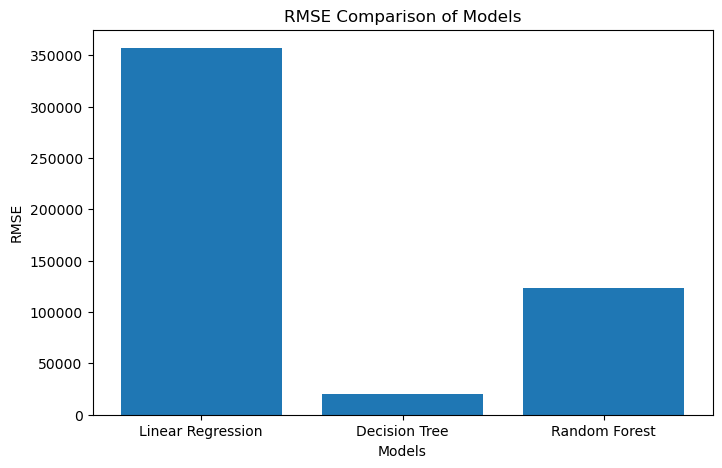

In [90]:
models = ["Linear Regression", "Decision Tree", "Random Forest"]
rmse = [lin_rmse, dec_rmse, ran_rmse]

plt.figure(figsize=(8,5))
plt.bar(models, rmse)

plt.title("RMSE Comparison of Models")
plt.xlabel("Models")
plt.ylabel("RMSE")

/var/folders/3f/pjbcw57d5hqcm79gpvnjlbsh0000gn/T/ipykernel_1071/942896754.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


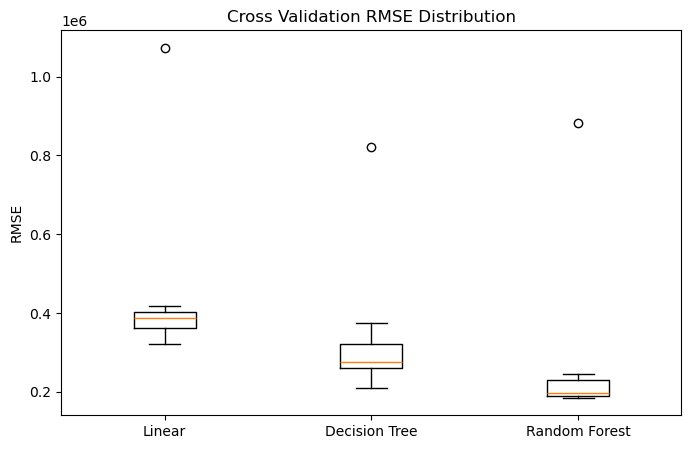

In [91]:
plt.figure(figsize=(8,5))

plt.boxplot(
    [lin_rmses, dec_rmses, ran_rmses],
    labels=["Linear", "Decision Tree", "Random Forest"]
)

plt.title("Cross Validation RMSE Distribution")
plt.ylabel("RMSE")

plt.show()

In [ ]:
###

In [76]:
from sklearn.metrics import r2_score


In [77]:
test_features = full_pipeline.transform(strat_test_set.drop("selling_price", axis=1))
test_labels = strat_test_set["selling_price"]

test_pred = ran_reg.predict(test_features)

In [84]:
Test_score=r2_score(test_labels, test_pred)
Train_score=r2_score(car_labels, ran_pred)
print("Test R2 score is ",Test_score)

print("Training R2 score is ",Train_score)

Test R2 score is  0.8708869813408875
Training R2 score is  0.9813006419908741


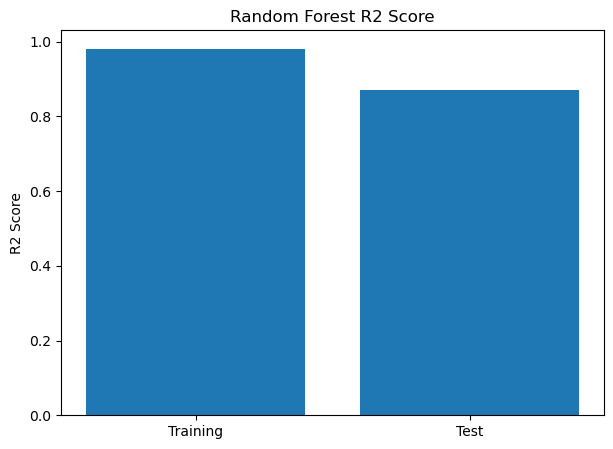

In [95]:
import matplotlib.pyplot as plt

scores = [Train_score, Test_score]
labels = ["Training", "Test"]

plt.figure(figsize=(7,5))
plt.bar(labels, scores)
plt.title("Random Forest R2 Score")
plt.ylabel("R2 Score")
plt.show()